<div style="text-align: justify; max-width: 90ch">

# Lecture 01 exercises (solutions)

Exercises are tagged with the goal they practise (see `reading_material/goals_01.md`); `[O]` marks stretch exercises. Time bands:

- 15 min (quick)
- 45 min (realistic)
- 90 min (stretch)

Run the configuration cell first; Ollama must be running with the models pulled, as in the lectures.

</div>

In [1]:
import json
import os
import subprocess
from pathlib import Path

import ollama
import pandas as pd
from dotenv import load_dotenv
from huggingface_hub import HfApi, ModelCard
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama

In [2]:
# --- Course configuration: edit TIER only; settings in .env (Read: 01d_env_hugging_face) ---
TIER = "cpu"  # 8-16 GB RAM, no GPU (default)
# TIER = "gpu"  # >= 8 GB VRAM: bigger, better answers (pull qwen3:8b first)

REPO = Path.cwd().resolve().parents[1]  # runs from a lecture subfolder
load_dotenv(REPO / ".env")  # load your .env settings: OLLAMA_HOST, HF_TOKEN, ...
TIER = os.environ.get("COURSE_TIER", TIER)  # tools/run_all.py can override
from huggingface_hub.utils import disable_progress_bars

disable_progress_bars()  # no download bars in saved outputs (works after the imports)
CHAT_MODEL = {"cpu": "qwen3:1.7b", "gpu": "qwen3:8b"}[TIER]
EMBED_MODEL = "nomic-embed-text"
OLLAMA_HOST = os.environ.get("OLLAMA_HOST", "http://localhost:11434")
MLFLOW_URI = os.environ.get("MLFLOW_TRACKING_URI", "http://127.0.0.1:5010")
# To override .env in this notebook only, uncomment and edit (never a token):
# OLLAMA_HOST = "http://192.168.1.20:11434"
# MLFLOW_URI = "http://127.0.0.1:5011"
EXPERIMENT = "llm-course-01-exercises"
DATA_DIR = REPO / "data"  # gitignored runtime state (indexes, caches)

from llm_course.checks import check_ollama

check_ollama(OLLAMA_HOST, [CHAT_MODEL])

Ollama OK at http://localhost:11434; models ready: qwen3:1.7b


<div style="text-align: justify; max-width: 90ch">

### Exercise 1.1 [G1, G7] Your hardware report (15 min)

Run `llmfit` from Python (as in `lec_01b` section 5) and show the five best-fitting models for your machine. In a Markdown cell below the table,
state which `TIER` you will use in this course and give two reasons taken from the table (memory, speed, or fit).

</div>

In [3]:
def llmfit(*args):
    result = subprocess.run(
        ["llmfit", *args, "--json"], capture_output=True, text=True, timeout=180
    )
    return json.loads(result.stdout)["models"]


columns = [
    "name",
    "params_b",
    "memory_required_gb",
    "fit_label",
    "estimated_tps",
    "run_mode",
]

pd.DataFrame(llmfit("recommend"))[columns].head(5)

,name,params_b,memory_required_gb,fit_label,estimated_tps,run_mode
0,Qwen/Qwen2.5-Coder-7B-Instruct-GPTQ-Int4,7.62,4.75,Good,38.1,GPU
1,Qwen/Qwen2.5-Coder-7B-Instruct-AWQ,7.62,4.75,Good,38.1,GPU
2,Qwen/CodeQwen1.5-7B-AWQ,7.25,4.63,Good,40.1,GPU
3,Qwen/Qwen2.5-7B-Instruct-AWQ,7.62,4.75,Good,38.1,GPU
4,Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4,7.62,4.75,Good,38.1,GPU


<div style="text-align: justify; max-width: 90ch">

**Example answer.** Read `run_mode`, `fit_label` and `estimated_tps` in your table.

- If 7-8B models run on the GPU with fit `Good` and 30+ estimated tokens/s (about 38 in one example run on a machine with a GPU),
  `TIER = "gpu"` is an option.
- If they run on the CPU only at a few tokens/s, take `TIER = "cpu"`: on one example laptop without a GPU, `llmfit plan "Qwen/Qwen3-8B" --quant Q4_K_M --context 8192` estimated about 3 tokens/s,
  far from interactive, while the 1.7B model was estimated above 10 tokens/s, enough for a chat.

</div>

<div style="text-align: justify; max-width: 90ch">

### Exercise 1.2 [G5, G6, G7] Choose a model for a business scenario (45 min)

Pick **one** scenario:

- **A. Greek customer support.** A retailer wants an assistant that answers customer questions in Greek, on a server inside the company (privacy),
  on a machine with 16 GB of RAM and no GPU.
- **B. Code assistant for a product.** A startup will ship a coding helper inside its commercial product; English only; it must be allowed to sell it;
  latency matters more than size.
- **C. Contract summaries.** A law office wants summaries of 50-page contracts (English); nothing may leave the office; a workstation with a 24 GB GPU is available.

1. Write the requirements table for the scenario in a Markdown cell (the eight rows from `lec_01b` section 1).
2. Search the Hub with filters that match at least two requirements (language tag, `pipeline_tag`, a size or format keyword) and show the top results.
3. Load the model cards of two candidates and show license, languages and base model.
4. For your preferred candidate, list its GGUF quantizations and sizes, and pick one that fits the scenario's hardware.
5. Write the decision record.

</div>

<div style="text-align: justify; max-width: 90ch">

**Scenario A: Greek customer support** (example solution)

| Requirement | Scenario A |
| --- | --- |
| Task | answer customer questions from a product FAQ (RAG), polite tone |
| Languages | Greek in and out; English product names |
| License | permissive (Apache-2.0 / MIT) or vendor terms that allow commercial use |
| Context | 8k tokens (FAQ excerpts plus conversation) |
| Latency | 10+ tokens/s; customers wait |
| Hardware and cost | 16 GB RAM, CPU only: a 4-bit model of at most ~8B parameters |
| Privacy | on-premises only |
| Maintenance | an actively updated family, European-language focus is a plus |

</div>

In [4]:
api = HfApi()

greek_candidates = api.list_models(
    pipeline_tag="text-generation", filter="el", sort="downloads", limit=10
)

pd.DataFrame(
    [
        {"model": m.id, "downloads": m.downloads, "likes": m.likes}
        for m in greek_candidates
    ]
)

,model,downloads,likes
0,utter-project/EuroLLM-22B-Instruct-2512,269623,86
1,utter-project/EuroLLM-1.7B-Instruct,230880,104
2,facebook/xglm-564M,56088,54
3,bartowski/c4ai-command-r7b-12-2024-GGUF,48194,16
4,speakleash/Bielik-11B-v3.0-Instruct-awq,26918,4
5,BSC-LT/salamandra-7b-instruct,26220,84
6,RedHatAI/Qwen2.5-7B-Instruct-FP8-dynamic,23993,1
7,CohereLabs/aya-expanse-8b,20086,454
8,utter-project/EuroLLM-9B-Instruct-2512,17952,16
9,utter-project/EuroLLM-1.7B,17728,120


In [5]:
rows = []

for repo in ["utter-project/EuroLLM-1.7B-Instruct", "Qwen/Qwen3-4B"]:
    data = ModelCard.load(repo).data.to_dict()
    rows.append(
        {
            "model": repo,
            "license": data.get("license"),
            "languages": data.get("language"),
            "base_model": data.get("base_model"),
        }
    )

pd.DataFrame(rows)

,model,license,languages,base_model
0,utter-project/EuroLLM-1.7B-Instruct,apache-2.0,"[en, de, es, fr, it, pt, pl, nl, tr, sv, cs, e...",[utter-project/EuroLLM-1.7B]
1,Qwen/Qwen3-4B,apache-2.0,None,[Qwen/Qwen3-4B-Base]


In [6]:
info = api.model_info("unsloth/Qwen3-4B-GGUF", files_metadata=True)

gguf = pd.DataFrame(
    [
        {"file": s.rfilename, "size_gb": round(s.size / 1e9, 2)}
        for s in info.siblings
        if s.rfilename.endswith(".gguf")
    ]
).sort_values("size_gb")

gguf[gguf["file"].str.contains("Q4_K_M|Q8_0|Q6_K")]

,file,size_gb
9,Qwen3-4B-Q4_K_M.gguf,2.50
13,Qwen3-4B-Q6_K.gguf,3.31
24,Qwen3-4B-UD-Q6_K_XL.gguf,3.66
14,Qwen3-4B-Q8_0.gguf,4.28


<div style="text-align: justify; max-width: 90ch">

- **Decision:** `Qwen3-4B` at `Q4_K_M` (about 2.5 GB), with `EuroLLM-1.7B-Instruct` as the fallback to test on real Greek tickets.
- **Requirements:**
  - Greek support chat over a FAQ
  - commercial use
  - 8k context
  - 10+ tok/s on a 16 GB CPU machine
  - on-premises
- **Candidates checked:**
  - EuroLLM-1.7B (Apache-2.0, Greek listed explicitly, small)
  - Qwen3-4B (Apache-2.0, "100+ languages", stronger general quality)
  - Llama 3.2 (no Greek: rejected)
  - Gemma 3 (custom terms: legal review needed)
- **Evidence:**
  - model cards (license, languages)
  - GGUF sizes
  - llmfit fit on the target machine (to check there)
  - a Greek prompt test on both (still to run)
- **Revisit when:** EuroLLM releases a larger instruct model, or the machine gets a GPU.

</div>

<div style="text-align: justify; max-width: 90ch">

### Exercise 1.3 [G2, G5] Compare two models on five fixed questions (45 min)

Reuse the `compare` function from `lec_01b` section 6 (copy it here). Compare `qwen3:1.7b` with a second model you have pulled (`qwen3:0.6b`,
or the candidate from Exercise 1.2) on five questions of your own:

- three about the Python course
- one in Greek
- one that needs a short calculation

Show the table and write two sentences: which requirement each model fails, if any.

</div>

In [7]:
client = ollama.Client(host=OLLAMA_HOST)


def compare(models, prompts):
    rows = []
    for model in models:
        for name, prompt in prompts.items():
            response = client.chat(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                think=False,
                options={"temperature": 0, "num_predict": 80},
            )
            rows.append(
                {
                    "model": model,
                    "prompt": name,
                    "tok_per_s": round(
                        response.eval_count / (response.eval_duration / 1e9), 1
                    ),
                    "answer": response.message.content.strip().replace("\n", " ")[:110],
                }
            )
    return pd.DataFrame(rows)


my_prompts = {
    "pandas": "In one sentence, what does groupby do in pandas?",
    "sklearn": "In one sentence, why do we use cross-validation?",
    "plots": "Which seaborn function draws a heatmap? Answer with the function name only.",
    "greek": "Σε μία πρόταση, τι είναι το overfitting; Απάντησε στα ελληνικά.",
    "calculation": "A dataset has 1200 rows. With test_size=0.25, how many rows are in the test set? Answer with the number only.",
}

compare(["qwen3:0.6b", CHAT_MODEL], my_prompts)

,model,prompt,tok_per_s,answer
0,qwen3:0.6b,pandas,224.0,"In pandas, `groupby` is used to group data bas..."
1,qwen3:0.6b,sklearn,263.7,Cross-validation is used to assess the general...
2,qwen3:0.6b,plots,290.3,seabornheatmap
3,qwen3:0.6b,greek,292.0,"Στην πρόταση, το **overfitting** είναι η προκύ..."
4,qwen3:0.6b,calculation,304.0,"With a test size of 0.25, the number of rows i..."
5,qwen3:1.7b,pandas,152.4,Groupby in pandas is used to split a DataFrame...
6,qwen3:1.7b,sklearn,166.9,We use cross-validation to assess the generali...
7,qwen3:1.7b,plots,315.8,heatmap
8,qwen3:1.7b,greek,159.3,Το **overfitting** είναι η περίπτωση όταν ένα ...
9,qwen3:1.7b,calculation,200.0,400


<div style="text-align: justify; max-width: 90ch">

### Exercise 1.4 [G4] Temperature sweep (15 min)

For the prompt "Suggest a name for a data science podcast. Answer with the name only.", run three calls at each of `temperature` 0, 0.5 and 1.0.
Build a DataFrame and count the number of *distinct* answers per temperature.

</div>

In [8]:
prompt = "Suggest a name for a data science podcast. Answer with the name only."

rows = []

for temperature in [0.0, 0.5, 1.0]:
    for run in range(3):
        answer = client.chat(
            model=CHAT_MODEL,
            messages=[{"role": "user", "content": prompt}],
            think=False,
            options={"temperature": temperature, "num_predict": 20},
        ).message.content.strip()
        rows.append({"temperature": temperature, "run": run + 1, "answer": answer})

sweep = pd.DataFrame(rows)

display(sweep)

,temperature,run,answer
0,0.0,1,DataNexus
1,0.0,2,DataSphere
2,0.0,3,DataSphere
3,0.5,1,DataNexus
4,0.5,2,DataSphere
5,0.5,3,DataSphere
6,1.0,1,DataSphere
7,1.0,2,DataForge
8,1.0,3,DataSphere


In [9]:
sweep.groupby("temperature")["answer"].nunique().rename("distinct answers")

temperature
0.0    2
0.5    2
1.0    2
Name: distinct answers, dtype: int64

<div style="text-align: justify; max-width: 90ch">

### Exercise 1.5 [G9] Classify 20 support tickets (45 min)

The list below holds 20 IT help-desk tickets.

1. Write a JSON schema with two fields, `category` (one of `hardware`, `software`, `account`, `network`, `other`) and `urgency` (`low`,
   `medium`, `high`).
2. Include short category definitions in the prompt.
3. Tag every ticket with structured output.
4. Build a DataFrame, and plot the number of tickets per category.

Cache the results to a CSV in `DATA_DIR` so the cell is cheap to re-run.

```python
tickets = [
    "My laptop will not turn on after the update",
    "I cannot log in to the university email",
    "Excel crashes every time I open a file larger than 50 MB",
    "The Wi-Fi in the library drops every ten minutes",
    "Please reset my password, I forgot it",
    "The projector in room B12 shows no signal",
    "Teams says my account is disabled",
    "Python is not recognised as a command in the terminal",
    "The printer on the third floor is out of toner",
    "VPN connects but I cannot reach the file server",
    "My screen flickers when I plug in the external monitor",
    "I need access to the shared research folder",
    "Jupyter opens but the kernel keeps dying",
    "The classroom PCs boot to a black screen",
    "Two-factor codes never arrive on my phone",
    "Zoom audio is choppy on the campus network",
    "My keyboard types the wrong characters",
    "Git push asks for a password and then fails",
    "The e-class site says my session expired",
    "Battery drains in one hour even when idle",
]
```

</div>

In [10]:
tickets = [
    "My laptop will not turn on after the update",
    "I cannot log in to the university email",
    "Excel crashes every time I open a file larger than 50 MB",
    "The Wi-Fi in the library drops every ten minutes",
    "Please reset my password, I forgot it",
    "The projector in room B12 shows no signal",
    "Teams says my account is disabled",
    "Python is not recognised as a command in the terminal",
    "The printer on the third floor is out of toner",
    "VPN connects but I cannot reach the file server",
    "My screen flickers when I plug in the external monitor",
    "I need access to the shared research folder",
    "Jupyter opens but the kernel keeps dying",
    "The classroom PCs boot to a black screen",
    "Two-factor codes never arrive on my phone",
    "Zoom audio is choppy on the campus network",
    "My keyboard types the wrong characters",
    "Git push asks for a password and then fails",
    "The e-class site says my session expired",
    "Battery drains in one hour even when idle",
]

TICKET_SCHEMA = {
    "type": "object",
    "properties": {
        "category": {
            "type": "string",
            "enum": ["hardware", "software", "account", "network", "other"],
        },
        "urgency": {"type": "string", "enum": ["low", "medium", "high"]},
    },
    "required": ["category", "urgency"],
}

DEFINITIONS = """Categories:
- hardware: laptops, screens, printers, projectors, batteries, keyboards
- software: applications, installations, crashes, command-line tools
- account: passwords, logins, permissions, two-factor codes
- network: Wi-Fi, VPN, connectivity, audio or video quality online
- other: anything else
Urgency: high if the person cannot work at all, medium if a workaround exists, low otherwise."""


def tag_ticket(ticket):
    response = client.chat(
        model=CHAT_MODEL,
        messages=[
            {
                "role": "user",
                "content": f"Tag this IT ticket.\n\n{DEFINITIONS}\n\nTicket: {ticket}",
            }
        ],
        format=TICKET_SCHEMA,
        think=False,
        options={"temperature": 0, "num_predict": 60},
    )
    return json.loads(response.message.content)


cache_path = DATA_DIR / "lec_01_exercise_tickets.csv"
DATA_DIR.mkdir(exist_ok=True)

if cache_path.exists():
    tagged = pd.read_csv(cache_path)
else:
    tagged = pd.DataFrame([{"ticket": t, **tag_ticket(t)} for t in tickets])
    tagged.to_csv(cache_path, index=False)

display(tagged)

,ticket,category,urgency
0,My laptop will not turn on after the update,hardware,high
1,I cannot log in to the university email,account,high
2,Excel crashes every time I open a file larger ...,software,high
3,The Wi-Fi in the library drops every ten minutes,network,medium
4,"Please reset my password, I forgot it",account,high
5,The projector in room B12 shows no signal,hardware,high
6,Teams says my account is disabled,account,high
7,Python is not recognised as a command in the t...,software,high
8,The printer on the third floor is out of toner,hardware,high
9,VPN connects but I cannot reach the file server,network,high


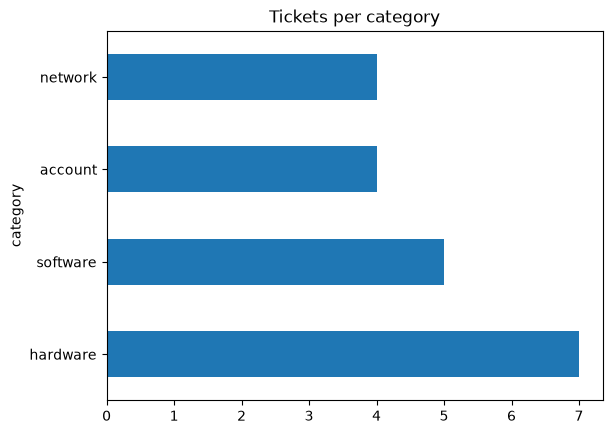

In [11]:
tagged["category"].value_counts().plot(kind="barh", title="Tickets per category");

<div style="text-align: justify; max-width: 90ch">

### Exercise 1.6 [G10] A Greek tutor chain and its rendered prompt (15 min)

Build a LangChain chain whose system prompt makes the model answer in Greek in at most two sentences. Print the rendered system and user messages the model will receive (as in `lec_01d` section 2),
then run the chain on a course question.

</div>

In [12]:
llm = ChatOllama(
    model=CHAT_MODEL,
    base_url=OLLAMA_HOST,
    reasoning=False,
    temperature=0,
    num_predict=150,
)

prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Είσαι βοηθός διδασκαλίας σε μάθημα Python. Απάντησε στα ελληνικά, σε το πολύ {sentences} προτάσεις.",
        ),
        ("human", "{question}"),
    ]
)

inputs = {
    "sentences": 2,
    "question": "What is the difference between a list and a tuple?",
}

for message in prompt.invoke(inputs).messages:  # what the model will receive
    print(f"[{message.type}] {message.content}")

[system] Είσαι βοηθός διδασκαλίας σε μάθημα Python. Απάντησε στα ελληνικά, σε το πολύ 2 προτάσεις.
[human] What is the difference between a list and a tuple?


In [13]:
chain = prompt | llm | StrOutputParser()

print(chain.invoke(inputs))

Ένας λίστας είναι αναδιατακτικός και μπορεί να αλλαξθεί, ενώ ένας τυπικός τυποποιημένος τύπος (tuple) είναι αδιατακτικός και αρχικοποιείται.


<div style="text-align: justify; max-width: 90ch">

### Exercise 1.7 [O2] Hosted inference swap (45 min, stretch)

Following `lec_01f`, configure a hosted OpenAI-compatible endpoint in `.env` (Hugging Face inference providers with your `HF_TOKEN`,
or any other provider), run the chain from Exercise 1.6 against it, and compare:

- latency
- tokens billed
- whether the Greek is better

Write three sentences on which requirements changed.

</div>

In [14]:
from langchain_openai import ChatOpenAI

if (
    os.environ.get("HOSTED_BASE_URL")
    and os.environ.get("HOSTED_API_KEY")
    and os.environ.get("HOSTED_MODEL")
):
    hosted_llm = ChatOpenAI(
        model=os.environ["HOSTED_MODEL"],
        base_url=os.environ["HOSTED_BASE_URL"],
        api_key=os.environ["HOSTED_API_KEY"],
        temperature=0,
    )

    hosted_reply = (prompt | hosted_llm).invoke(inputs)

    print(hosted_reply.content)
    print(hosted_reply.usage_metadata)  # tokens in and out: what the provider bills
else:
    print("No hosted endpoint in .env; see lec_01f section 2 for the variables to set.")

No hosted endpoint in .env; see lec_01f section 2 for the variables to set.


<div style="text-align: justify; max-width: 90ch">

### Exercise 1.8 [O1] The model without the server (90 min, stretch)

Following `lec_01e`, load `Qwen/Qwen3-0.6B` with `transformers`, generate 60 tokens for the same prompt with and without Ollama,
and report:

- memory (parameters × bytes)
- tokens per second
- whether the two answers agree

</div>

In [15]:
# See lec_01e: sections 2, 4 and 5 contain the complete solution; run them and record the two tokens/s numbers here.